In [18]:
#!/usr/bin/env python
# coding: utf-8

# # Ukraine Battlefield Analysis - Combined View
# This notebook combines:
# - Area-specific calculations for Vovchansk (or other regions)
# - Full Ukraine interactive map with color-coded territories

# ## Cell 1: Imports and Setup

import pymongo
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape, Polygon, Point, box
from shapely import wkt
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()

user = os.getenv("MONGODB_USER")
pwd = os.getenv("MONGODB_PWD")
cluster = os.getenv("CLUSTER")

if not user or not pwd:
    raise ValueError("Missing credentials! Please check your .env file.")

connection_string = f"mongodb+srv://{user}:{pwd}@{cluster}"
client = pymongo.MongoClient(connection_string)




In [20]:
# ## Cell 2: Load Historical Data from MongoDB

geom_field = 'geometry'
db = client['geodb']
collection = db['geodata']
data = list(collection.find({}))
df = pd.DataFrame(data)

if geom_field in df.columns:
    df[geom_field] = df[geom_field].apply(lambda x: shape(x) if x else None)

gdf_historical = gpd.GeoDataFrame(df, geometry=geom_field)
print(f"Loaded {len(gdf_historical)} records from MongoDB")


# ## Cell 3: Define Areas of Interest

Pokrovsk = {
    "top_left": (48.38635420778455, 36.99714660644532),
    "bottom_right": (48.25576986959547, 37.26013183593751)
}

Olenokoistiantynivka = {
    "top_left": (47.81592114659014, 36.05506896972657),
    "bottom_right": (47.66168780332917, 36.31393432617188)
}

Oleksandrivka = {
    "top_left": (48.20, 36.10),
    "bottom_right": (47.75, 36.70)
}


Bilohiria = {
    "top_left": (47.65058757118736, 35.897140502929695),
    "bottom_right": (47.48658499815577, 36.13746643066407)
}

Varachyne = {
    "top_left": (51.24558425850245, 34.70443725585938),
    "bottom_right": (51.06729071974382, 35.22903442382813)
}

eastern_donbas = {
    "top_left": (50.450509053586615, 35.67260742187501),
    "bottom_right": (48.73445537176822, 38.35327148437501)
}

Vovchansk = {
    "top_left": (50.32, 36.90),
    "bottom_right": (50.25, 37.10)
}

#februrary 6, 2026 offemsive
Kolmakov = {
    "top_left": (51.42490192575532, 34.55749511718751),
    "bottom_right": (50.96015671954614, 35.72204589843751)
}



Borova = {
    "top_left": ( 49.96888926176223, 36.32629394531251),
    "bottom_right": (48.87194147722911, 38.1500244140625)
        }
Borova = {
    "top_left": (49.520, 37.520),
    "bottom_right": (49.200, 37.980)
}

Huliaipole = {
 "top_left": (47.850, 35.900),
    "bottom_right": (47.450, 36.500)
                 }

# zelenaksy tells media 300 km gained

Ternuvate = {
    "top_left": (47.923704717745686, 35.99670410156251),
"bottom_right": (47.833439707627605, 36.50344848632813)
}


Kostiantynivka = {

    "top_left": (48.5720639570219, 37.55813598632813),
"bottom_right": (48.4720108081634, 37.83004760742188)
}


Kostyantynivka = {
    "top_left": (48.590, 37.650),
    "bottom_right": (48.250, 38.180)
}


Stepnohirsk =  { "top_left": ( 47.643648727772906, 35.26679992675782),
                          "bottom_right": (47.57652571374621, 35.389022827148445)
}

Slovyansk_East = {
    "top_left": (48.980, 37.820),
    "bottom_right": (48.620, 38.300)
}


# Select area to analyze
area = Huliaipole
area_name = "Huliaipole"  # Change this to match your selection




Loaded 22551 records from MongoDB


In [21]:
# ## Cell 4: Clip Historical Data to Selected Area

pt1 = (area["top_left"][0], area["top_left"][1])
pt2 = (area["bottom_right"][0], area["bottom_right"][1])
min_lon, max_lon = sorted([pt1[1], pt2[1]])
min_lat, max_lat = sorted([pt1[0], pt2[0]])
mask = box(min_lon, min_lat, max_lon, max_lat)

gdf_area = gdf_historical.clip(mask)
gdf_area.set_crs(epsg=4326, inplace=True)
gdf_area = gdf_area.to_crs(epsg=32636)

print(f"Clipped to {len(gdf_area)} features in {area_name}")


Clipped to 1214 features in Huliaipole


In [22]:
# ## Cell 5: Process Area Data and Calculate Statistics

gdf_area['dt'] = pd.to_datetime(gdf_area['epoch_time'], unit='s')
gdf_area = gdf_area.set_index('dt')

polygons_area = gdf_area[
    gdf_area.geometry.apply(lambda x: isinstance(x, Polygon))
].copy()

def extract_first_part(name, part=0):
    """Splits the DeepState name string and returns the specific index requested."""
    first_part = name.split('///')[part].strip()
    return first_part

polygons_area['name'] = polygons_area['properties'].apply(lambda x: x['name'])
polygons_area['name'] = polygons_area['name'].apply(lambda x: extract_first_part(x, 1))

km_factor = 1_000_000  # Use 1 for square meters, 1_000_000 for square km

def calculate_snapshot_areas(cdf):
    mask_occupied = cdf['name'].str.contains("occupied", case=False, na=False)
    mask_liberated = cdf['name'].str.contains("liberated", case=False, na=False)
    mask_gray = cdf['name'].str.contains("unknown", case=False, na=False)
    
    return pd.Series({
        'liberated': int(cdf.loc[mask_liberated].area.sum() / km_factor),
        'occupied': int(cdf.loc[mask_occupied].area.sum() / km_factor),
        'gray': int(cdf.loc[mask_gray].area.sum() / km_factor)
    })

polygons_area.index = polygons_area.index.normalize()
df_stats = polygons_area.groupby(level=0).apply(calculate_snapshot_areas).sort_index()

df_pct_change = (df_stats.pct_change() * 100).add_suffix(' Δ %')

final_df = pd.concat([df_stats, df_pct_change], axis=1)
final_df = final_df[[
    'liberated', 'liberated Δ %',
    'occupied', 'occupied Δ %',
    'gray', 'gray Δ %',
]]
final_df = final_df.fillna(0)

print(f"\nArea Statistics for {area_name} (Square Meters):")
final_df.round(4).tail(10)


Area Statistics for Huliaipole (Square Meters):


,liberated,liberated Δ %,occupied,occupied Δ %,gray,gray Δ %
dt,,,,,,
2026-08-12,69,165.3846,1158,-2.9338,167,-6.7039
2026-08-13,70,1.4493,1158,0.0000,167,0.0000
2026-08-14,70,0.0000,1158,0.0000,167,0.0000
2026-08-21,70,0.0000,1171,1.1226,166,-0.5988
2026-08-23,70,0.0000,1171,0.0000,182,9.6386
2026-08-25,70,0.0000,1171,0.0000,182,0.0000
2026-08-26,70,0.0000,1171,0.0000,182,0.0000
2026-08-27,70,0.0000,1171,0.0000,182,0.0000
2026-08-30,70,0.0000,1177,0.5124,175,-3.8462


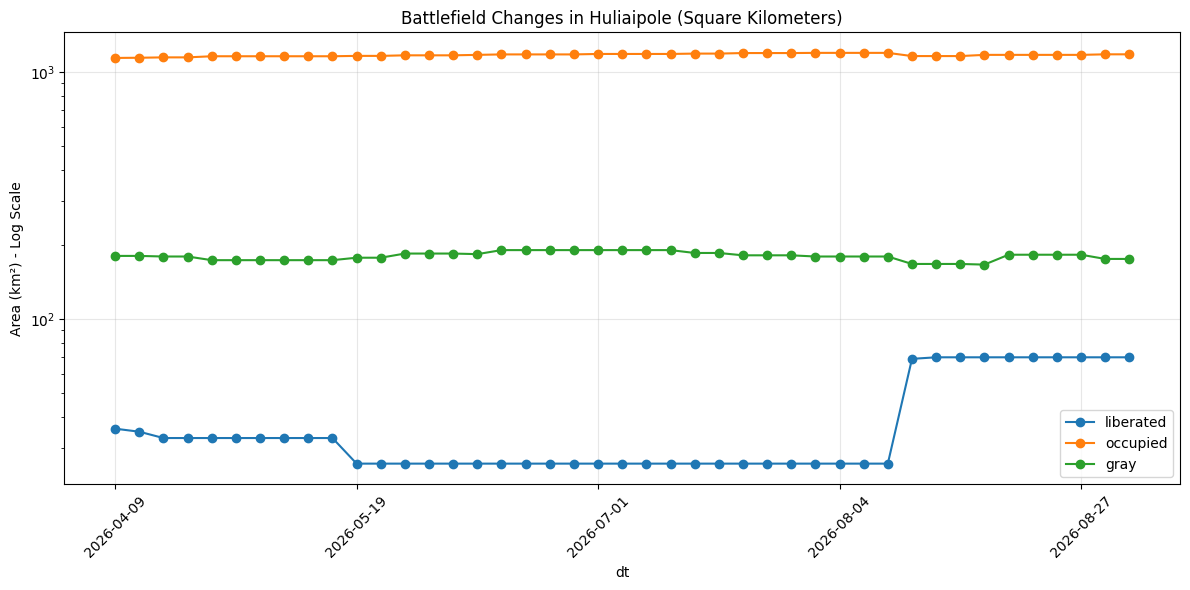

In [23]:
# ## Cell 6: Plot Time Series for Selected Area

df_plot = final_df[['liberated', 'occupied', 'gray']]
df_plot = df_plot.loc[~(df_plot == 0).all(axis=1)]
df_plot = df_plot.dropna(how='all')

if len(df_plot) > 0:
    df_plot.index = df_plot.index.strftime('%Y-%m-%d')
    
    df_plot.plot(marker='o', figsize=(12, 6), logy=True, rot=45)
    plt.title(f"Battlefield Changes in {area_name} (Square Kilometers)")
    plt.ylabel("Area (km²) - Log Scale")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



In [24]:
# ## Cell 7: Load Current Full Ukraine Map from DeepState API

import requests

url = 'https://deepstatemap.live/api/history/last'
response = requests.get(url)

if response.status_code == 200:
    deep_state_data_raw = response.json()
    
    geo_list = []
    for f in deep_state_data_raw['map']['features']:
        geom = f['geometry']
        name = f['properties']['name']
        clean_geometry = wkt.loads(wkt.dumps(shape(geom), output_dimension=2))
        new_feature = {
            "name": name,
            "geometry": clean_geometry
        }
        geo_list.append(new_feature)
    
    for item in geo_list:
        item['name'] = extract_first_part(item['name'], part=1)
    
    gdf_ukraine = gpd.GeoDataFrame(geo_list)
    gdf_ukraine = gdf_ukraine.set_crs(4326)
    
    polygons_ukraine = gdf_ukraine[
        gdf_ukraine.geometry.apply(lambda x: isinstance(x, Polygon))
    ].copy()
    
    print(f"Loaded {len(polygons_ukraine)} polygons from DeepState API")
    
    # Calculate totals
    polygons_ukraine_proj = polygons_ukraine.to_crs(epsg=32636)
    targets = ['CADR and CALR', 'Occupied', 'Occupied Crimea']
    occupied_areas = polygons_ukraine_proj[polygons_ukraine_proj['name'].isin(targets)].copy()
    liberated_areas = polygons_ukraine_proj[
        polygons_ukraine_proj["name"].str.contains("liberated", case=False, na=False)
    ].copy()
    gray_areas = polygons_ukraine_proj[
        polygons_ukraine_proj["name"].str.contains("unknown", case=False, na=False)
    ].copy()
    
    km = 1_000_000
    print(f"\nFull Ukraine Statistics:")
    print(f"  Liberated areas: {int(liberated_areas.area.sum() / km)} km²")
    print(f"  Occupied areas: {int(occupied_areas.area.sum() / km)} km²")
    print(f"  Gray areas: {int(gray_areas.area.sum() / km)} km²")
else:
    print(f"Error fetching  {response.status_code}")



Loaded 124 polygons from DeepState API

Full Ukraine Statistics:
  Liberated areas: 41272 km²
  Occupied areas: 117174 km²
  Gray areas: 1711 km²


In [25]:
# ## Cell 8: Create Interactive Map with ipyleaflet

from ipyleaflet import Map, basemaps, GeoJSON, LayersControl, Rectangle
import json

# Get latest snapshot from area analysis
polygons_latest = polygons_area[polygons_area.index == polygons_area.index.max()].copy()

# Combine full Ukraine polygons with area-specific polygons
# Convert both to lat/lon (EPSG:4326)
polygons_ukraine_ll = polygons_ukraine.copy()  # Already in 4326
polygons_latest_ll = polygons_latest.to_crs(epsg=4326)

# Create combined GeoDataFrame
all_polygons = pd.concat([polygons_ukraine_ll, polygons_latest_ll], ignore_index=True)

# Keep only necessary columns
cols = ["name", "geometry"]
gdf_view = all_polygons[cols]

# Convert to GeoJSON
data = json.loads(gdf_view.to_json())

# Define styling function
def status_style(feature):
    name = (feature.get("properties", {}) or {}).get("name", "") or ""
    name_lower = name.lower()
    
    if "liberated" in name_lower:
        fill = "blue"
    elif "occupied" in name_lower:
        fill = "red"
    elif "unknown" in name_lower:
        fill = "gray"
    else:
        fill = "black"
    
    return {
        "color": "black",
        "weight": 2,
        "fillColor": fill,
        "fillOpacity": 0.4,
    }

# Create map centered on Ukraine
ukraine_center = gdf_ukraine.geometry.unary_union.centroid
m = Map(center=(ukraine_center.y, ukraine_center.x), zoom=6, basemap=basemaps.OpenStreetMap.Mapnik)

# Add all polygons
m.add_layer(GeoJSON(
    data=data,
    style={"opacity": 1, "fillOpacity": 0.4, "weight": 2},
    style_callback=status_style,
))

# Add rectangle showing analyzed area
top_left = area["top_left"]
bottom_right = area["bottom_right"]
min_lat_rect, max_lat_rect = sorted([top_left[0], bottom_right[0]])
min_lon_rect, max_lon_rect = sorted([top_left[1], bottom_right[1]])

rect = Rectangle(
    bounds=[(min_lat_rect, min_lon_rect), (max_lat_rect, max_lon_rect)],
    color="yellow",
    weight=3,
    fill=False,
)

m.add_layer(rect)
m.add_control(LayersControl())

# Display the map
m

/var/folders/yl/cbhtz34d3cd3b1dpt3rrvpf40000gn/T/ipykernel_9809/406308336.py:46: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ukraine_center = gdf_ukraine.geometry.unary_union.centroid


Map(center=[51.42912499108607, 46.940136711055004], controls=(ZoomControl(options=['position', 'zoom_in_text',…